## Visualizing Contrast between Two Experiments

### Import package

In [11]:
import json
import numpy as np

from pathlib import Path
from scipy.integrate import trapezoid

from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.fontsize": 12,
    "figure.titlesize": 18,
    "contour.negative_linestyle": "dashed",
})

### Load composite structure for the two experiments

In [12]:
INPUT_DIR: Path = Path("/home/b11209013/Manuscript_Prep/KW_CRI/File")
FIG_DIR: Path = Path("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/experiment_contrast")

FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load NoRad experiment
norad_composite: dict[str, np.ndarray] = dict(
    np.load(
        INPUT_DIR / "NoRad_Composite.npz"
        )
    )

# Load CldRad experiment
cldrad_composite: dict[str, np.ndarray] = dict(
    np.load(
        INPUT_DIR / "CldRad_Composite.npz"
        )
    )

# extract coordinates
x: np.ndarray = norad_composite["coord_x"]
z: np.ndarray = norad_composite["coord_z"]

NX, NZ = x.size, z.size


### Visualize contrast of generation between experiments

#### Domain Setup

In [13]:
# Shared style, matching the ERA5 composite notebook.
FIGURE_DIR = Path("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/model_composite")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
NORAD_DIR = FIGURE_DIR / "NoRad"
NORAD_DIR.mkdir(parents=True, exist_ok=True)

LONGITUDE_LIMIT = 30.0

# The rolling step places the convective center at NX // 2.
metres_per_degree = 2 * np.pi * 6.371e6 / 360.0
x_rel = (x - x[NX // 2]) / metres_per_degree
height_km = z / 1000.0
visible = np.abs(x_rel) <= LONGITUDE_LIMIT

#### Helper functions

In [14]:
def _remove_zero_contour(
        data: np.ndarray
) -> np.ndarray:

    total_level = MaxNLocator(nbins=8).tick_values(
        np.nanmin(data), np.nanmax(data),
        )

    total_level = np.asarray(
        MaxNLocator(nbins=10).tick_values(
            np.nanmin(data),
            np.nanmax(data),
        ),
        dtype=float,
    )
    # Scale the zero tolerance to the field so small source terms retain contours.
    zero_tolerance = np.max(np.abs(total_level)) * 1e-12
    return total_level[~np.isclose(total_level, 0.0, atol=zero_tolerance, rtol=0.0)]

#### Visualizing

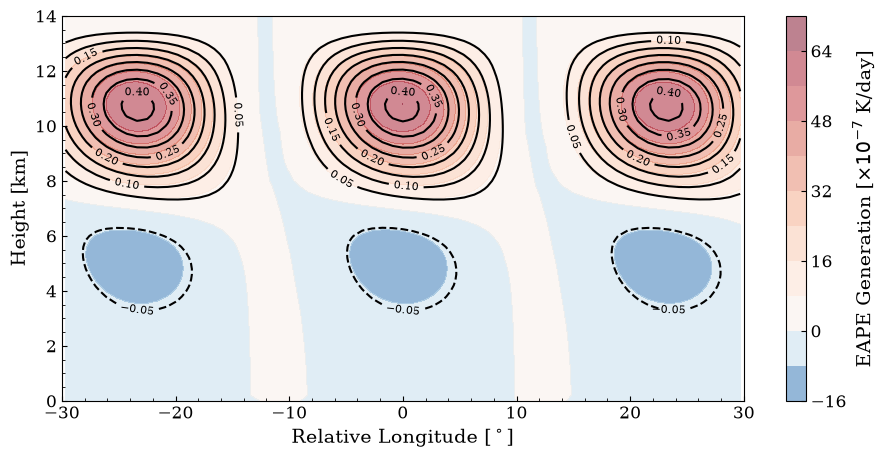

In [15]:
fig, ax = plt.subplots(1 ,1, figsize=(11, 5))

norad_gen_ctf = plt.contourf(
    x_rel[visible], height_km,
    norad_composite["source"][:, visible]*1e7,
    levels=11,
    alpha=0.5,
    cmap="RdBu_r",
    norm=TwoSlopeNorm(0.0)
)
cldrad_gen_ct = plt.contour(
    x_rel[visible], height_km,
    cldrad_composite["source"][:, visible]*1e7,
    levels=_remove_zero_contour(cldrad_composite["source"][:, visible]*1e7),
    colors="k"
)
ax.minorticks_on()
ax.tick_params(direction="in")
ax.set_xlim(-LONGITUDE_LIMIT, LONGITUDE_LIMIT)
ax.set_xlabel(r"Relative Longitude [$^\circ$]")
ax.set_ylabel("Height [km]")
plt.colorbar(norad_gen_ctf, ax=ax, label=r"EAPE Generation [$\times 10^{-7}$ K/day]")
plt.clabel(cldrad_gen_ct, inline=True, fontsize=8)
plt.savefig(FIG_DIR / "gen_contrast.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

### Convective heating profiles averaged over the positive phase

Overlay NoRad and CldRad using each experiment's own positive phase of the
**composite** vertically integrated heating:

$$I(x) = \int_{z_{\min}}^{z_{\max}} J(z,x)\,dz, \qquad
\overline{J}_{+}(z) = \frac{1}{N_{+}}\sum_{x:\,I(x)>0} J(z,x).$$

Integrate over height with the trapezoidal rule (no density weighting), then
average equally over selected longitude columns on the uniform grid. Selection
uses the full longitude domain, independently for each experiment; it is not
restricted to the ±30° window of the preceding plot. Negative values at individual
heights are retained when the column integral is positive. Columns with nonfinite
heating are excluded. These are spatial averages of the saved composites, which
have already been averaged over time and ensemble members.

The larger left panel overlays the 2D J composites (NoRad shading and CldRad
contours). The right panel shares the height axis and shows NoRad as a solid
black line and CldRad as a dashed black line, with light gray shading between them.


NoRad: averaging 402 / 801 columns
CldRad: averaging 403 / 801 columns


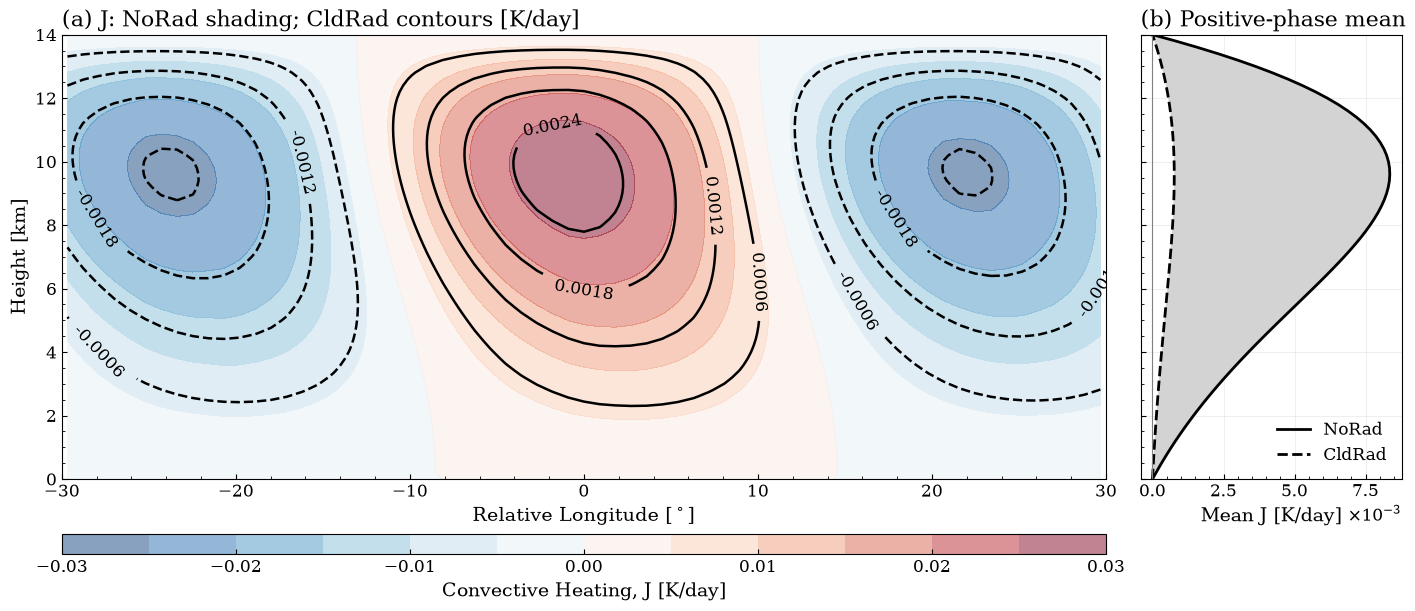

In [16]:
# Select the positive phase using the column integral, not J at each height.
J_positive_profiles = {}
J_column_integrals = {}
J_positive_masks = {}

for name, composite in [("NoRad", norad_composite), ("CldRad", cldrad_composite)]:
    heating = np.asarray(composite["J"], dtype=float)
    heights = np.asarray(composite["coord_z"], dtype=float)
    if heating.shape != (heights.size, composite["coord_x"].size):
        raise ValueError(f"{name}: J must have shape (height, longitude).")
    if not np.all(np.isfinite(heights)) or not np.all(np.diff(heights) > 0):
        raise ValueError(f"{name}: heights must be finite and strictly increasing.")

    column_integral = trapezoid(heating, x=heights, axis=0)
    positive_phase = (
        np.all(np.isfinite(heating), axis=0)
        & np.isfinite(column_integral)
        & (column_integral > 0.0)
    )
    if not np.any(positive_phase):
        raise ValueError(f"{name}: no columns have positive integrated heating.")

    J_column_integrals[name] = column_integral  # K m/day
    J_positive_masks[name] = positive_phase
    J_positive_profiles[name] = heating[:, positive_phase].mean(axis=1)
    print(f"{name}: averaging {positive_phase.sum()} / {positive_phase.size} columns")

# Both panels show convective heating J; the left panel uses the ±30° window.
# A shared vertical grid is needed to shade between the mean profiles.
if not np.array_equal(norad_composite["coord_z"], cldrad_composite["coord_z"]):
    raise ValueError("The profile overlay requires matching height coordinates.")

cldrad_x = cldrad_composite["coord_x"]
cldrad_x_rel = (cldrad_x - cldrad_x[cldrad_x.size // 2]) / metres_per_degree
cldrad_visible = np.abs(cldrad_x_rel) <= LONGITUDE_LIMIT
norad_J = norad_composite["J"][:, visible]
cldrad_J = cldrad_composite["J"][:, cldrad_visible]

fig = plt.figure(figsize=(14, 6), constrained_layout=True)
grid = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 0.045])
composite_ax = fig.add_subplot(grid[0, 0])
profile_ax = fig.add_subplot(grid[0, 1], sharey=composite_ax)
cbar_ax = fig.add_subplot(grid[1, 0])

J_limit = 0.03
J_shading = composite_ax.contourf(
    x_rel[visible], height_km, norad_J,
    levels=np.linspace(-J_limit, J_limit, 13),
    cmap="RdBu_r", norm=TwoSlopeNorm(vmin=-J_limit, vcenter=0, vmax=J_limit),
    alpha=0.5
)
J_contours = composite_ax.contour(
    cldrad_x_rel[cldrad_visible], cldrad_composite["coord_z"] / 1000.0,
    cldrad_J, levels=_remove_zero_contour(cldrad_J), colors="k", linewidths=1.8,
)
composite_ax.clabel(J_contours, inline=True, fontsize=12, fmt="%.4f")
composite_ax.set_xlim(-LONGITUDE_LIMIT, LONGITUDE_LIMIT)
composite_ax.set_ylim(height_km[0], height_km[-1])
composite_ax.set_xlabel(r"Relative Longitude [$^\circ$]")
composite_ax.set_ylabel("Height [km]")
composite_ax.set_title("(a) J: NoRad shading; CldRad contours [K/day]", loc="left")
cbar = fig.colorbar(
    J_shading, cax=cbar_ax, orientation="horizontal",
    label="Convective Heating, J [K/day]",
)

cbar.set_ticks([-0.03, -0.020, -0.01, 0.000, 0.01, 0.02, 0.03])

profile_ax.fill_betweenx(
    height_km, J_positive_profiles["NoRad"], J_positive_profiles["CldRad"],
    color="lightgray", zorder=1,
)
for name, linestyle in [("NoRad", "-"), ("CldRad", "--")]:
    profile_ax.plot(
        J_positive_profiles[name], height_km,
        color="k", linestyle=linestyle, linewidth=2, label=name, zorder=2,
    )
profile_ax.axvline(0.0, color="0.5", linewidth=0.8)
profile_ax.set_xlabel("Mean J [K/day]")
profile_ax.set_title("(b) Positive-phase mean", loc="left")
profile_ax.ticklabel_format(axis="x", style="sci", scilimits=(-2, 2), useMathText=True)
profile_ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
profile_ax.tick_params(labelleft=False)
profile_ax.grid(alpha=0.2)
profile_ax.set_axisbelow(True)
profile_ax.legend(frameon=False)
for ax in (composite_ax, profile_ax):
    ax.minorticks_on()
    ax.tick_params(direction="in")

fig.savefig(FIG_DIR / "J_composite_and_profiles.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


### Temperature and vertical velocity contrasts

Use the same layout and styling as the heating comparison. The vertical means of
T and w use each experiment's **positive vertically integrated J mask**, over the
full longitude domain, so all three variables sample the same convective phase.
NoRad is shaded in the 2D panels and CldRad is contoured; right-panel means use
solid and dashed black lines, respectively, with light gray shading between them.

The w figure also includes the saved full-field DCIN [K] below the 2D panel,
sharing its relative-longitude axis. No background or longitude mean is removed.
The model uses time in days; reconstructed w is plotted in m/day without rescaling.


In [17]:
# Reuse the heating-based phase selection for T and w.
T_positive_profiles = {
    name: composite["T"][:, J_positive_masks[name]].mean(axis=1)
    for name, composite in [("NoRad", norad_composite), ("CldRad", cldrad_composite)]
}
w_positive_profiles = {
    name: composite["w"][:, J_positive_masks[name]].mean(axis=1)
    for name, composite in [("NoRad", norad_composite), ("CldRad", cldrad_composite)]
}


def plot_variable_contrast(variable, profiles, units, label, limit, contour_fmt,
                           include_dcin=False, display_name=None):
    """Match the J contrast layout, with optional DCIN below the left panel."""
    display_name = variable if display_name is None else display_name
    fig = plt.figure(figsize=(14, 8 if include_dcin else 6), constrained_layout=True)
    height_ratios = [1, 0.3, 0.045] if include_dcin else [1, 0.045]
    grid = fig.add_gridspec(
        len(height_ratios), 2, width_ratios=[4, 1], height_ratios=height_ratios,
    )
    composite_ax = fig.add_subplot(grid[0, 0])
    profile_ax = fig.add_subplot(grid[0, 1], sharey=composite_ax)
    cbar_ax = fig.add_subplot(grid[-1, 0])

    shading = composite_ax.contourf(
        x_rel[visible], height_km, norad_composite[variable][:, visible],
        levels=np.linspace(-limit, limit, 13), cmap="RdBu_r",
        norm=TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit), alpha=0.5,
        extend="both",
    )
    cldrad_values = cldrad_composite[variable][:, cldrad_visible]
    contours = composite_ax.contour(
        cldrad_x_rel[cldrad_visible], cldrad_composite["coord_z"] / 1000.0,
        cldrad_values, levels=_remove_zero_contour(cldrad_values),
        colors="k", linewidths=1.8,
    )
    composite_ax.clabel(contours, inline=True, fontsize=12, fmt=contour_fmt)
    composite_ax.set_xlim(-LONGITUDE_LIMIT, LONGITUDE_LIMIT)
    composite_ax.set_ylim(height_km[0], height_km[-1])
    composite_ax.set_ylabel("Height [km]")
    composite_ax.set_title(
        f"(a) {display_name}: NoRad shading; CldRad contours [{units}]", loc="left",
    )
    cbar = fig.colorbar(
        shading, cax=cbar_ax, orientation="horizontal", label=f"{label} [{units}]",
    )
    cbar.set_ticks(np.linspace(-limit, limit, 7))

    profile_ax.fill_betweenx(
        height_km, profiles["NoRad"], profiles["CldRad"],
        color="lightgray", zorder=1,
    )
    for name, linestyle in [("NoRad", "-"), ("CldRad", "--")]:
        profile_ax.plot(
            profiles[name], height_km, color="k", linestyle=linestyle,
            linewidth=2, label=name, zorder=2,
        )
    profile_ax.axvline(0.0, color="0.5", linewidth=0.8)
    profile_ax.set_xlabel(f"Mean {display_name} [{units}]")
    profile_ax.set_title("(b) Positive-phase mean", loc="left")
    profile_ax.ticklabel_format(axis="x", style="sci", scilimits=(-2, 2), useMathText=True)
    profile_ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    profile_ax.tick_params(labelleft=False)
    profile_ax.grid(alpha=0.2)
    profile_ax.set_axisbelow(True)
    profile_ax.legend(frameon=False)
    axes = [composite_ax, profile_ax]

    if include_dcin:
        dcin_ax = fig.add_subplot(grid[1, 0], sharex=composite_ax)
        composite_ax.tick_params(labelbottom=False)
        for name, composite, relative_x, mask, linestyle in [
            ("NoRad", norad_composite, x_rel, visible, "-"),
            ("CldRad", cldrad_composite, cldrad_x_rel, cldrad_visible, "--"),
        ]:
            dcin_ax.plot(
                relative_x[mask], composite["DCIN"][mask],
                color="k", linestyle=linestyle, linewidth=2, label=name,
            )
        dcin_ax.set_title("(c) DCIN", loc="left")
        dcin_ax.set_ylabel("DCIN [K]")
        dcin_ax.set_xlabel(r"Relative Longitude [$^\circ$]")
        dcin_ax.ticklabel_format(axis="y", style="plain", useOffset=False)
        dcin_ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
        dcin_ax.grid(alpha=0.2)
        dcin_ax.legend(frameon=False, ncol=2, loc="best")
        axes.append(dcin_ax)
    else:
        composite_ax.set_xlabel(r"Relative Longitude [$^\circ$]")

    for ax in axes:
        ax.minorticks_on()
        ax.tick_params(direction="in")
    suffix = "_DCIN" if include_dcin else ""
    fig.savefig(
        FIG_DIR / f"{variable}_composite_and_profiles{suffix}.png",
        dpi=300, bbox_inches="tight",
    )
    fig.savefig(
        FIG_DIR / f"{variable}_composite_and_profiles{suffix}.pdf",
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)


#### Temperature contrast


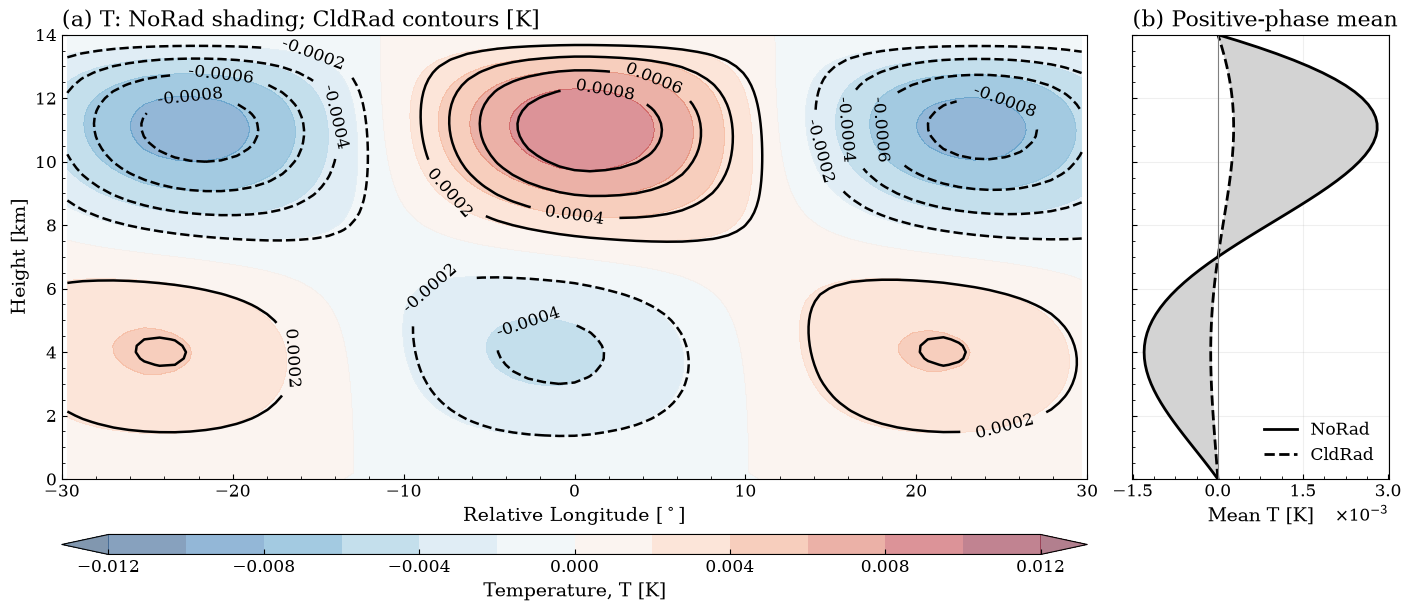

In [18]:
plot_variable_contrast(
    "T", T_positive_profiles, units="K", label="Temperature, T",
    limit=0.012, contour_fmt="%.4f",
)


#### Vertical velocity and DCIN contrast


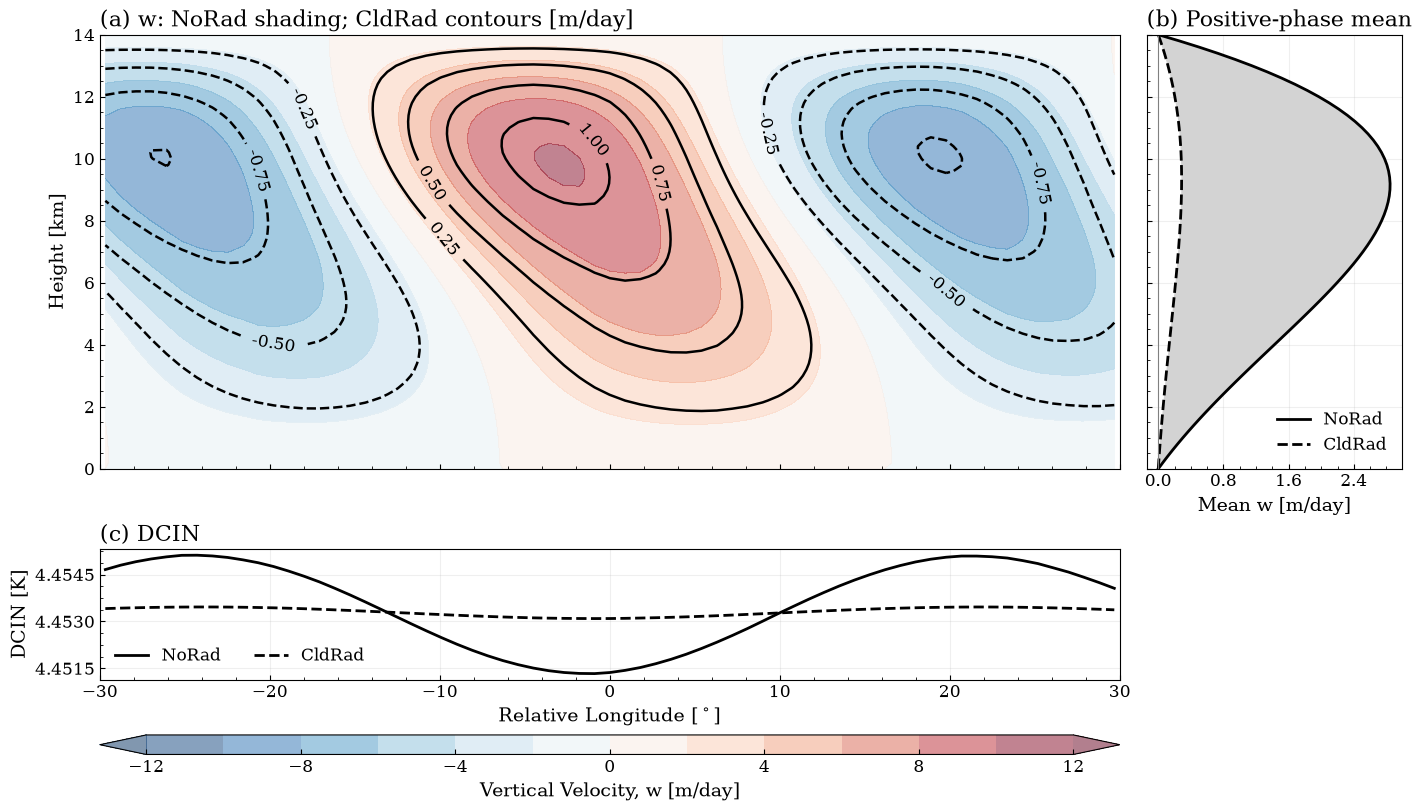

In [19]:
plot_variable_contrast(
    "w", w_positive_profiles, units="m/day", label="Vertical Velocity, w",
    limit=12.0, contour_fmt="%.2f", include_dcin=True,
)


### Second-mode source: composite and vertical-profile contrast

The left panel overlays the second-mode source composites within ±30° relative
longitude: NoRad shading and CldRad black contours. The right panel shares the
height axis and compares the vertical profiles, using solid black for NoRad and
dashed black for CldRad, with light gray shading between them.

The saved `T2J2` field contains S₂ = (T2 × J2 / T_bar) × Γ_d / (Γ_d − Γ), in K/day.
As for J, T, and w, the profiles average each experiment's positive vertically
integrated heating phase (`J_positive_masks`) over the full longitude domain.
Negative source values are retained. Both experiments use the original source
amplitudes without normalization.


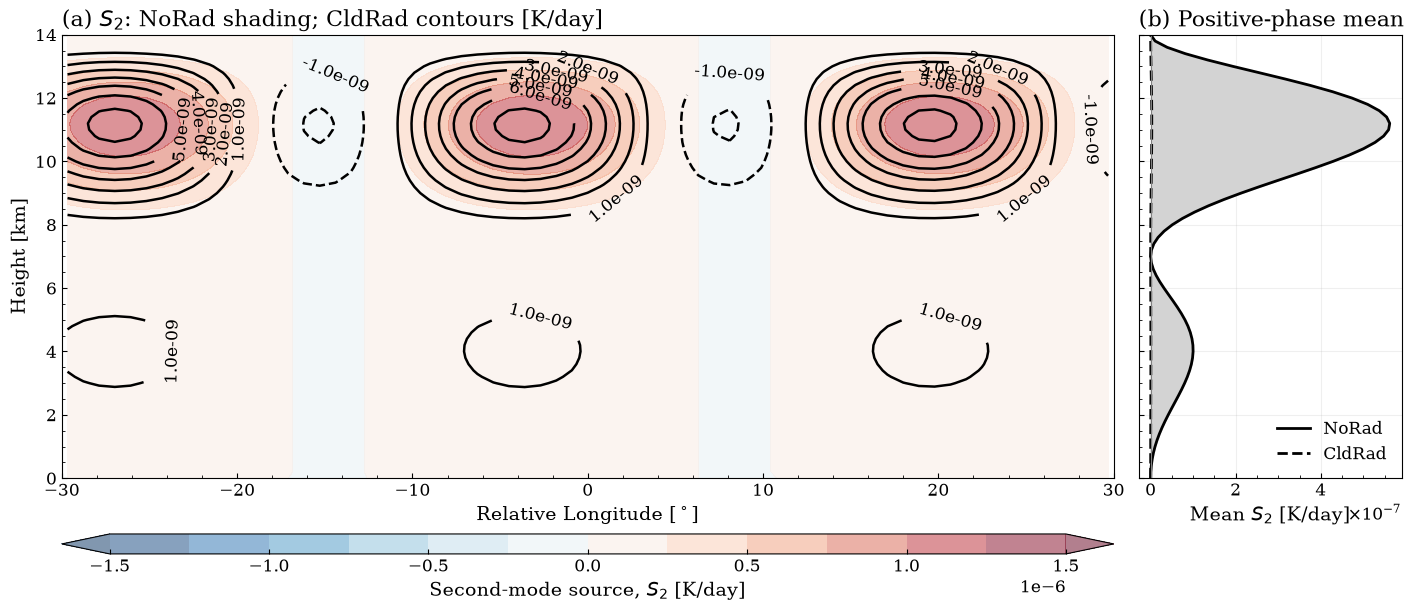

In [20]:
# Reuse the same heating-based phase selection as the other vertical profiles.
T2J2_positive_profiles = {}
for name, composite in [("NoRad", norad_composite), ("CldRad", cldrad_composite)]:
    if "T2J2" not in composite:
        raise KeyError(f"{name}: rerun Composite.ipynb to save the T2J2 composite.")
    product = np.asarray(composite["T2J2"], dtype=float)
    if product.shape != composite["J"].shape:
        raise ValueError(f"{name}: T2J2 and J must share the (height, longitude) grid.")
    T2J2_positive_profiles[name] = product[:, J_positive_masks[name]].mean(axis=1)

if not np.array_equal(norad_composite["coord_z"], cldrad_composite["coord_z"]):
    raise ValueError("The profile overlay requires matching height coordinates.")
# Match the left-composite/right-profile layout of the J, T, and w figures.
plot_variable_contrast(
    "T2J2", T2J2_positive_profiles,
    units="K/day", label=r"Second-mode source, $S_2$",
    limit=1.5e-6, contour_fmt="%.1e", display_name=r"$S_2$",
)
